In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from hmf import MassFunction

In [ ]:

# -----------------------------
# Constants
# -----------------------------
h = 0.7
H0 = h * 100
Om0 = 0.318
sigma8 = 0.8
Mmin = 1e13  # Msun / h
Mmax = 1e15  # Msun / h
area_deg2 = 5000.0

# Fixed redshift bin (selection function = 1)
zmin, zmax = 0.3, 0.5
z_mid = 0.5 * (zmin + zmax)

# -----------------------------
# Cosmology & helper
# -----------------------------
def volume_shell(zmin, zmax, Om0, area_deg2):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    V = (cosmo.comoving_volume(zmax) - cosmo.comoving_volume(zmin)).to(u.Mpc**3).value
    V /= h**3
    f_sky = area_deg2 / 41253.0
    return V * f_sky  # Mpc^3/h^3

V_shell = volume_shell(zmin, zmax, Om0, area_deg2)

# -----------------------------
# Mass bins
# -----------------------------
nM = 10
M_edges_logh = np.linspace(np.log10(Mmin), np.log10(Mmax), nM + 1)
M_centres_logh = 0.5 * (M_edges_logh[:-1] + M_edges_logh[1:])
M_centres = 10**M_centres_logh * h  # convert back to Msun

mf = MassFunction(
    z=z_mid,
    cosmo_params={"H0": H0, "Om0": Om0},
    sigma_8=sigma8,
    Mmin=np.log10(Mmin), Mmax=np.log10(Mmax),
    hmf_model="Tinker08",
)

# -----------------------------
# Function to compute counts
# -----------------------------
def compute_counts(M_edges_logh, add_noise=False, noise_sigma=0.1):
    N_counts = []
    for logMmin, logMmax in zip(M_edges_logh[:-1], M_edges_logh[1:]):
        if add_noise:
            logMmin += np.random.normal(0, noise_sigma)
            logMmax += np.random.normal(0, noise_sigma)

            # Ensure valid bin order and range
            if logMmax <= logMmin:
                logMmax = logMmin + 0.05
            logMmin = max(logMmin, np.log10(Mmin))
            logMmax = min(logMmax, np.log10(Mmax))

        mf.update(Mmin=logMmin, Mmax=logMmax, z=z_mid)
        if len(mf.m) < 2:
            N_counts.append(0)
            continue

        dM = np.gradient(mf.m)
        n_z = np.sum(mf.dndm * dM)
        N_counts.append(n_z * V_shell)
    return np.array(N_counts)

# -----------------------------
# Compute
# -----------------------------
np.random.seed(42)
N_counts_clean = compute_counts(M_edges_logh, add_noise=False)
N_counts_noisy = compute_counts(M_edges_logh, add_noise=True, noise_sigma=0.1)


<BarContainer object of 10 artists>

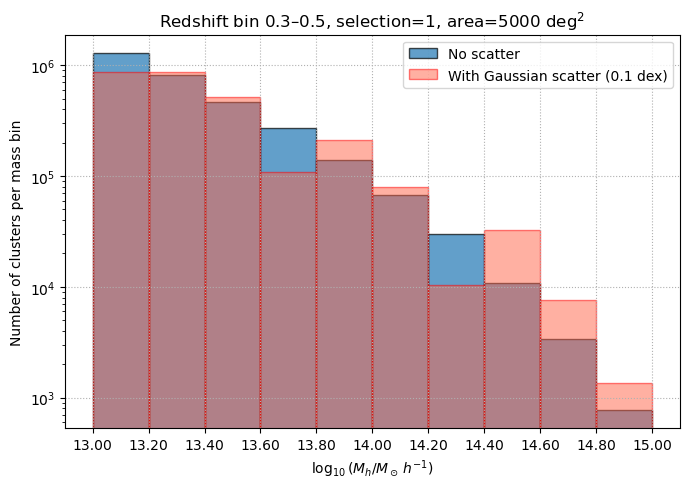

In [29]:
# -----------------------------
# Plot histogram (side-by-side bars)
# -----------------------------
# convert bin edges to linear mass (Msun/h)
M_edges = 10**M_edges_logh
widths = np.diff(M_edges)

widths_log = np.diff(M_edges_logh)

plt.figure(figsize=(7,5))

# histogram bars for no scatter
plt.bar(
    M_edges_logh[:-1], N_counts_clean, width=widths_log,
    align='edge', edgecolor='k', alpha=0.7, label='No scatter'
)

# histogram bars for scatter (slightly offset)
plt.bar(
    M_edges_logh[:-1], N_counts_noisy, width=widths_log,
    align='edge', edgecolor='r', color='tomato', alpha=0.5,
    label='With Gaussian scatter (0.1 dex)'
)

# make x-axis show every bin edge
plt.xticks(M_edges_logh, [f"{x:.2f}" for x in M_edges_logh])

#plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\log_{10}(M_h / M_\odot\,h^{-1})$')
plt.ylabel(r"Number of clusters per mass bin")
plt.title(fr"Redshift bin {zmin:.1f}–{zmax:.1f}, selection=1, area={area_deg2:.0f} deg$^2$")
plt.legend()
plt.grid(True, ls=":")
plt.tight_layout()
plt.show()
